In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Data preprocessing

## Import data and join tables

### Functions

In [2]:
def import_data():
    conditions = pd.read_csv('../raw_data/Conditions.txt', sep='\t')
    experiment_conditions = pd.read_csv('../raw_data/ExperimentConditions.txt', sep='\t')
    experiments = pd.read_csv('../raw_data/Experiments.txt', sep='\t', encoding='latin1')
    logcs = pd.read_csv('../raw_data/LogCs.txt', sep='\t')
    properties = pd.read_csv('../raw_data/Properties.txt', sep='\t')
    response_properties = pd.read_csv('../raw_data/ResponseProperties.txt', sep='\t')
    responses = pd.read_csv('../raw_data/Responses.txt', sep='\t', encoding='latin1')
    source = pd.read_csv('../raw_data/Source.txt', sep='\t')

    return conditions, experiment_conditions, experiments, logcs, properties, response_properties, responses, source

In [3]:
def remove_data_points(df, time_threshold=1000):
    # If we want to remove data points where the maximum time exceeds a certain treshold
    max_time = df.groupby('ResponseID', as_index=False).max('Time')
    include = max_time.loc[max_time['Time'] <= time_threshold]['ResponseID'].tolist()
    filtered_df = df[df['ResponseID'].isin(include)]

    return filtered_df

In [4]:
def merge_data(responses, experiments, experiment_conditions, source, response_properties, logcs):
    # Pivot ExperimentConditions table to have one row per ExperimentID before the merge
    experiment_conditions_pivot = experiment_conditions.pivot_table(index='ExperimentID', columns='ConditionID', values='Value').reset_index()
    experiment_conditions_pivot.fillna(0.101325, inplace=True)
    experiment_conditions_pivot.fillna(0, inplace=True)

    # Merge the tables to create a single DataFrame for analysis. Will join data based on the logcs table
    data = responses.merge(experiments, left_on='ExperimentID', right_on='ID', how='left').drop(columns=['ID_y']).rename(columns={'ID_x': 'ResponseID'})
    data = data.merge(experiment_conditions_pivot, on='ExperimentID', how='left')
    data = data.merge(response_properties, on='ResponseID', how='left').rename(columns={'Value_x': 'ResponseValue', 'Value_y': 'ResponsePropertiesValue'})
    data = data.merge(logcs, on='ResponseID', how='right')

    return data

### Explainations behind the functions...

In [5]:
# Import tables from the raw data directory
conditions = pd.read_csv('../raw_data/Conditions.txt', sep='\t')
experiment_conditions = pd.read_csv('../raw_data/ExperimentConditions.txt', sep='\t')
experiments = pd.read_csv('../raw_data/Experiments.txt', sep='\t', encoding='latin1')
logcs = pd.read_csv('../raw_data/LogCs.txt', sep='\t')
properties = pd.read_csv('../raw_data/Properties.txt', sep='\t')
response_properties = pd.read_csv('../raw_data/ResponseProperties.txt', sep='\t')
responses = pd.read_csv('../raw_data/Responses.txt', sep='\t', encoding='latin1')
source = pd.read_csv('../raw_data/Source.txt', sep='\t')

In [18]:
# Transform the LogCs table to have one row per ResponseID with a dictionay
logcs_dict = logcs.groupby('ResponseID').apply(
    lambda x: dict(zip(x['Time'], x['Value']))
).reset_index()

/tmp/ipykernel_419507/4111049196.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  logcs_dict = logcs.groupby('ResponseID').apply(


In [19]:
# Pivot ExperimentConditions table to have one row per ExperimentID before the merge
experiment_conditions_pivot = experiment_conditions.pivot_table(index='ExperimentID', columns='ConditionID', values='Value').reset_index()
experiment_conditions_pivot.fillna(0.101325, inplace=True)
experiment_conditions_pivot.fillna(0, inplace=True)

In [ ]:
# Merge the tables to create a single DataFrame for analysis
data = responses.merge(experiments, left_on='ExperimentID', right_on='ID', how='left').drop(columns=['ID_y']).rename(columns={'ID_x': 'ResponseID'})
data = data.merge(experiment_conditions_pivot, on='ExperimentID', how='left')
# Do we really need to merge 'Source'?
#data = data.merge(source, left_on='SourceID', right_on='ID', how='left').drop(columns=['ID'])
data = data.merge(response_properties, on='ResponseID', how='left').rename(columns={'Value_x': 'ResponseValue', 'Value_y': 'ResponsePropertiesValue'})
# Table 'Conditions' has no added value so it has not been merged
# Wait for this one since I have to look for DART
# data = data.merge(logcs_dict, on='ResponseID', how='left')

If we decide to remove some data...

In [21]:
# Determine the maximum time for each ResponseID
test = logcs.groupby('ResponseID')['Time'].max('Time')

In [22]:
# Determine the number of time points for each ResponseID
test1 = logcs.groupby('ResponseID')['Time'].count()

Text(0, 0.5, 'Frequency')

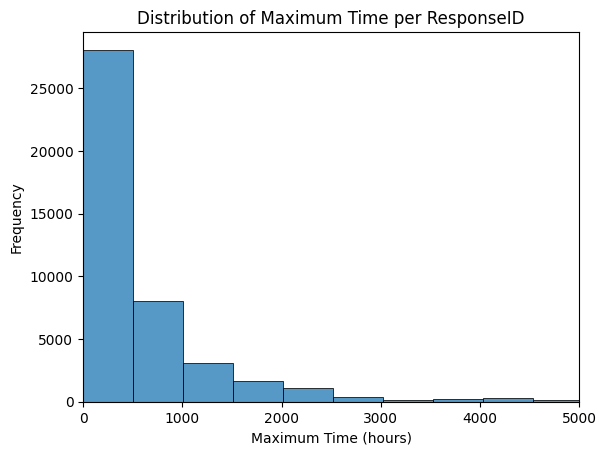

In [23]:
sns.histplot(test, binwidth=500)
plt.xlim(0, 5000)
plt.title('Distribution of Maximum Time per ResponseID')
plt.xlabel('Maximum Time (hours)')
plt.ylabel('Frequency')

From the graph above, the majority of the samples have a max time under 1000h. 
Only those samples will be used for the analysis. The rest will be considered 
outliers and removed from the dataset.

## Clean the dataset

In [5]:
conditions, experiment_conditions, experiments, logcs, properties, response_properties, responses, source = import_data()

In [6]:
data_merged = merge_data(responses, experiments, experiment_conditions, source, response_properties, remove_data_points(logcs, time_threshold=1000))

In [7]:
data_merged

,ResponseID,ExperimentID,Spec_rate,RateMethod,MethodID,OrganismID,OrganismSpecification,Comment,Logc0,LogcVar,...,sucrose,sugar,thymol,PropertyID,Value_x,ComBaseID_x,ID,Time,Value_y,ComBaseID_y
0,38733,39480.0,0.04053,NaN,plate_count,ah,Strain(s): CECT-398,NaN,NaN,5.96,...,0.101325,0.101325,0.101325,NaN,NaN,NaN,21,0.00,4.02,A_10
1,38733,39480.0,0.04053,NaN,plate_count,ah,Strain(s): CECT-398,NaN,NaN,5.96,...,0.101325,0.101325,0.101325,NaN,NaN,NaN,22,22.50,3.99,A_10
2,38733,39480.0,0.04053,NaN,plate_count,ah,Strain(s): CECT-398,NaN,NaN,5.96,...,0.101325,0.101325,0.101325,NaN,NaN,NaN,23,97.75,3.94,A_10
3,38733,39480.0,0.04053,NaN,plate_count,ah,Strain(s): CECT-398,NaN,NaN,5.96,...,0.101325,0.101325,0.101325,NaN,NaN,NaN,24,117.50,3.92,A_10
4,38733,39480.0,0.04053,NaN,plate_count,ah,Strain(s): CECT-398,NaN,NaN,5.96,...,0.101325,0.101325,0.101325,NaN,NaN,NaN,25,145.00,3.69,A_10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
372269,60418,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,419495,6.50,5.43,Lm_paneer_40C_T2
372270,60418,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,419496,17.00,6.70,Lm_paneer_40C_T2
372271,60418,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,419497,21.00,7.51,Lm_paneer_40C_T2
372272,60418,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,419498,24.00,7.79,Lm_paneer_40C_T2


In [8]:
data_merged['MatrixID'].value_counts()

MatrixID
culture_medium    175093
beef               25280
poultry            24396
produce            15012
seafood            14730
pork               14022
other/mix          13412
egg                 4697
sausage             3982
milk                3899
dairy_other         3174
dessert             2613
cheese              1817
meat_other          1769
infant_food         1693
beverage            1462
bread                992
water                523
sauce/dressing       376
grain                138
Name: count, dtype: int64

Since we want to predict food contamination, we should remove the data from
culture medium and keep only ['beef', 'poultry', 'produce', 'seafood', 'pork']. 
'other/mix' could be kept but it seems too undefined...

In [9]:
# Remove data for everything but ['beef', 'poultry', 'produce', 'seafood', 'pork']
food_matrices = ['beef', 'poultry', 'produce', 'seafood', 'pork']
filtered_data = data_merged[data_merged['MatrixID'].isin(food_matrices)]

In [10]:
# Quantity of samples per matrix
filtered_data.groupby('MatrixID')['ResponseID'].nunique()

MatrixID
beef       2303
pork       1542
poultry    2220
produce    1520
seafood    1354
Name: ResponseID, dtype: int64

In [11]:
filtered_data

,ResponseID,ExperimentID,Spec_rate,RateMethod,MethodID,OrganismID,OrganismSpecification,Comment,Logc0,LogcVar,...,sucrose,sugar,thymol,PropertyID,Value_x,ComBaseID_x,ID,Time,Value_y,ComBaseID_y
2241,116,116.0,NaN,NaN,plate_count,lm,NaN,Aerobic,NaN,0.63,...,NaN,NaN,NaN,NaN,NaN,NaN,2433,0.0,4.23,ADRIAN_01
2242,116,116.0,NaN,NaN,plate_count,lm,NaN,Aerobic,NaN,0.63,...,NaN,NaN,NaN,NaN,NaN,NaN,2434,24.0,4.15,ADRIAN_01
2243,116,116.0,NaN,NaN,plate_count,lm,NaN,Aerobic,NaN,0.63,...,NaN,NaN,NaN,NaN,NaN,NaN,2435,72.0,4.57,ADRIAN_01
2244,116,116.0,NaN,NaN,plate_count,lm,NaN,Aerobic,NaN,0.63,...,NaN,NaN,NaN,NaN,NaN,NaN,2436,144.0,4.23,ADRIAN_01
2245,116,116.0,NaN,NaN,plate_count,lm,NaN,Aerobic,NaN,0.63,...,NaN,NaN,NaN,NaN,NaN,NaN,2437,192.0,4.11,ADRIAN_01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
371962,60254,52374.0,NaN,NaN,mpn,ss,Species: S. Newport,NaN,NaN,4.07,...,NaN,NaN,NaN,NaN,NaN,NaN,418125,7.0,5.16,Sn_Cu_38C_2
371963,60255,52375.0,NaN,NaN,mpn,ss,Species: S. Newport,NaN,NaN,4.48,...,NaN,NaN,NaN,NaN,NaN,NaN,418126,1.0,1.25,Sn_Cu_38C_3
371964,60255,52375.0,NaN,NaN,mpn,ss,Species: S. Newport,NaN,NaN,4.48,...,NaN,NaN,NaN,NaN,NaN,NaN,418127,3.0,3.09,Sn_Cu_38C_3
371965,60255,52375.0,NaN,NaN,mpn,ss,Species: S. Newport,NaN,NaN,4.48,...,NaN,NaN,NaN,NaN,NaN,NaN,418128,5.0,4.67,Sn_Cu_38C_3


In [12]:
filtered_data.columns[filtered_data.isnull().any()], filtered_data.shape

(Index(['Spec_rate', 'RateMethod', 'MethodID', 'OrganismSpecification',
        'Comment', 'Logc0', 'Assumed', 'Ph', 'Aw', 'UserId', 'acetic_acid',
        'alta', 'apple_polyphenol', 'ascorbic_acid', 'benzoic_acid', 'betaine',
        'calcium_propionate', 'carvacrol', 'chitosan', 'cinnamaldehyde',
        'citric_acid', 'clo2', 'co2', 'dextrose', 'diacetic_acid', 'edta',
        'erythorbate', 'ethanol', 'fat', 'fructose', 'garlic', 'glucose',
        'glycerol', 'green_tea_leaf', 'green_tea_polyphenol', 'hcl', 'heated',
        'irradiated', 'irradiation', 'kcl', 'lactic_acid', 'lauricidin',
        'malic_acid', 'moisture', 'n2', 'nacl', 'nitrate', 'nitrite', 'o2',
        'oregano', 'pomegranate', 'potassium_lactate', 'potassium_sorbate',
        'pressure', 'propionic_acid', 'propylene_oxide', 'protein', 'rosemary',
        'sodium_lactate', 'sorbic_acid', 'sucrose', 'sugar', 'thymol',
        'PropertyID', 'Value_x', 'ComBaseID_x'],
       dtype='object'),
 (93440, 80))

In [13]:
filtered_data.isnull().sum()

ResponseID          0
ExperimentID        0
Spec_rate       66004
RateMethod      93440
MethodID          224
                ...  
ComBaseID_x     28455
ID                  0
Time                0
Value_y             0
ComBaseID_y         0
Length: 80, dtype: int64

In [18]:
filtered_data['moisture'].unique()

array([       nan,   0.101325, 100.      ,  85.      ,  60.      ,
        77.5     ,  77.3     ,  76.2     ,  76.7     ,  76.5     ,
        75.1     ,  75.2     ,  74.9     ,  77.2     ,  77.4     ,
        77.6     ,  77.7     ,  77.8     ,  77.9     ,  79.      ,
        30.      ,  57.5     ,  59.2     ,  75.6     ,  63.3     ,
        71.2     ,  66.      ,  63.7     ,  48.8     ,  56.5     ,
        63.8     ,  60.7     ,  94.6     ,  50.      ,  70.      ,
        90.      ,   0.      ])

Default values for every conditions (replace NA by...)

In [ ]:
fill_missing_values = {
    #'n2': 78.1,         # Must calculate the O2 and CO2 value too...
    'Temperature': 22,
    #'pH':,              # Use mean value from the in_on group
    #'Aw':,              # Use mean value from the in_on group
    'pressure': 0.101325,
    'acetic_acid':0,
    'alta':0,
    'apple_polyphenol':0,
    'ascorbic_acid':0,
    'benzoic_acid':0,
    'betaine':0,
    'calcium_propionate':0,
    'carvacrol':0,
    'chitosan':0,
    'cinnamaldehyde':0,
    'citric_acid':0,
    'clo2':0,
    #'co2':0.04,         # Must calculate the O2 and N2 value too...
    'dextrose':0,
    'diacetic_acid':0,
    'edta':0,
    'erythorbate':0,
    'ethanol':0,
    #'fat':,             # Use mean value from the in_on group or drop
    'fructose':0,
    'garlic':0,
    'glucose':0,
    'glycerol':0,
    'green_tea_leaf':0,
    'green_tea_polyphenol':0,
    'hcl':0,
    #'heated':,         # Drop this column
    'irradiated':0,
    'irradiation':0,
    'kcl':0,
    'lactic_acid':0,
    'lauricidin':0,
    'malic_acid':0,
    #'moisture':,        # Use mean value from the in_on group
    #'nacl':,            # Use mean value from the in_on group
    'nitrate':0,
    'nitrite':0,
    #'o2':21,              # Must calculate the N2 and CO2 value too...
    'oregano':0,
    'pomegranate':0,
    'potassium_lactate':0,
    'potassium_sorbate':0,
    'propionic_acid':0,
    'propylene_oxide':0,
    #'protein':,         # Use mean value from the in_on group or drop
    'rosemary':0,
    'sodium_lactate':0,
    'sorbic_acid':0,
    'sucrose':0,
    'sugar':0,
    'thymol':0
}

In [ ]:
# Columns to drop
columns_to_drop = ['Spec_rate', 'RateMethod', 'Logc0', 'CombaseID_x', 'heated']